In [5]:
import pandas as pd

# Load only the actual dataset sheet
df = pd.read_excel("E Commerce Dataset.xlsx", sheet_name="E Comm")

# Save as CSV
df.to_csv("ecommerce_churn.csv", index=False)

print("CSV Created Successfully!")

CSV Created Successfully!


In [29]:
import os

# Create folder to store all graphs
os.makedirs("visuals", exist_ok=True)

print("Visuals folder created successfully!")

Visuals folder created successfully!


In [30]:
import os
import warnings

import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Create visuals folder
os.makedirs("visuals", exist_ok=True)

In [6]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [7]:
from google.colab import files

files.download("ecommerce_churn.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
df.shape

(5630, 20)

In [9]:
df.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [10]:
df.tail()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
5625,55626,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,150.71
5626,55627,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,224.91
5627,55628,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186.42
5628,55629,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,178.90
5629,55630,0,8.0,Mobile Phone,1,15.0,Credit Card,Male,3.0,2,Laptop & Accessory,3,Married,4,0,13.0,2.0,2.0,3.0,169.04


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [12]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [14]:
df.isnull().sum()

,0
CustomerID,0
Churn,0
Tenure,264
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,251
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,255
NumberOfDeviceRegistered,0


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.nunique()

,0
CustomerID,5630
Churn,2
Tenure,36
PreferredLoginDevice,3
CityTier,3
WarehouseToHome,34
PreferredPaymentMode,7
Gender,2
HourSpendOnApp,6
NumberOfDeviceRegistered,6


In [17]:
df.describe(include="object")

,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
count,5630,5630,5630,5630,5630
unique,3,7,2,6,3
top,Mobile Phone,Debit Card,Male,Laptop & Accessory,Married
freq,2765,2314,3384,2050,2986


In [18]:
df["Churn"].value_counts()

,count
Churn,
0,4682
1,948


In [19]:
df["Churn"].value_counts(normalize=True)*100

,proportion
Churn,
0,83.161634
1,16.838366


In [20]:
df.dtypes

,0
CustomerID,int64
Churn,int64
Tenure,float64
PreferredLoginDevice,object
CityTier,int64
WarehouseToHome,float64
PreferredPaymentMode,object
Gender,object
HourSpendOnApp,float64
NumberOfDeviceRegistered,int64


## Dataset Understanding

The dataset contains customer demographic information, purchasing behavior, subscription history, and customer satisfaction attributes.

The target variable is **Churn**, which indicates whether a customer has left the company.

Before building any machine learning model, the dataset was examined to understand:

- Dataset dimensions
- Data types
- Missing values
- Duplicate records
- Numerical statistics
- Categorical distributions

This step helps ensure data quality before preprocessing and model training.

In [21]:
df.isnull().sum().sort_values(ascending=False)

,0
DaySinceLastOrder,307
OrderAmountHikeFromlastYear,265
Tenure,264
OrderCount,258
CouponUsed,256
HourSpendOnApp,255
WarehouseToHome,251
CustomerID,0
PreferredLoginDevice,0
Churn,0


In [22]:
missing = (df.isnull().sum()/len(df))*100

missing = missing.sort_values(ascending=False)

print(missing)

DaySinceLastOrder              5.452931
OrderAmountHikeFromlastYear    4.706927
Tenure                         4.689165
OrderCount                     4.582593
CouponUsed                     4.547069
HourSpendOnApp                 4.529307
WarehouseToHome                4.458259
CustomerID                     0.000000
PreferredLoginDevice           0.000000
Churn                          0.000000
PreferredPaymentMode           0.000000
CityTier                       0.000000
SatisfactionScore              0.000000
PreferedOrderCat               0.000000
NumberOfDeviceRegistered       0.000000
Gender                         0.000000
Complain                       0.000000
NumberOfAddress                0.000000
MaritalStatus                  0.000000
CashbackAmount                 0.000000
dtype: float64


In [23]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :",duplicates)

Duplicate Rows : 0


In [24]:
categorical_columns = df.select_dtypes(include='object').columns

numerical_columns = df.select_dtypes(exclude='object').columns

print("Categorical Columns")
print(categorical_columns)

print("\nNumerical Columns")
print(numerical_columns)

Categorical Columns
Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
      dtype='object')

Numerical Columns
Index(['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome',
       'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore',
       'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear',
       'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')


In [25]:
for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_1161/4165145500.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [26]:
for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_1161/4176552985.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [27]:
df.isnull().sum()

,0
CustomerID,0
Churn,0
Tenure,0
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,0
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,0
NumberOfDeviceRegistered,0


In [28]:
df["Churn"].value_counts()

,count
Churn,
0,4682
1,948


## Data Cleaning

The dataset was cleaned before model development.

The following preprocessing steps were performed:

- Checked missing values
- Calculated missing percentage
- Removed duplicate rows
- Identified numerical and categorical features
- Filled missing numerical values using the median
- Filled missing categorical values using the mode
- Verified the cleaned dataset

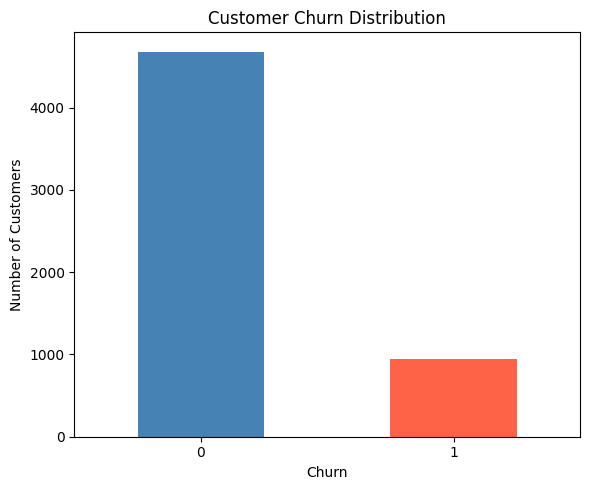

In [31]:
import matplotlib.pyplot as plt

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6,5))

churn_counts.plot(
    kind="bar",
    color=["steelblue","tomato"]
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("visuals/churn_distribution.png",dpi=300)

plt.show()

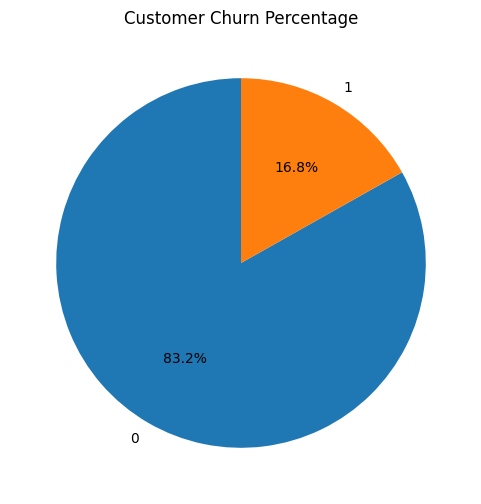

In [32]:
plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Customer Churn Percentage")

plt.savefig("visuals/churn_percentage.png",dpi=300)

plt.show()

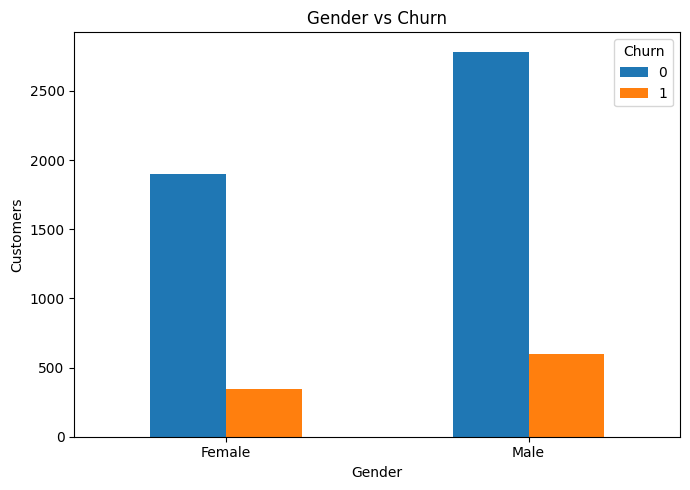

In [33]:
gender_churn = pd.crosstab(df["Gender"],df["Churn"])

gender_churn.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Gender vs Churn")

plt.xlabel("Gender")

plt.ylabel("Customers")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("visuals/gender_vs_churn.png",dpi=300)

plt.show()

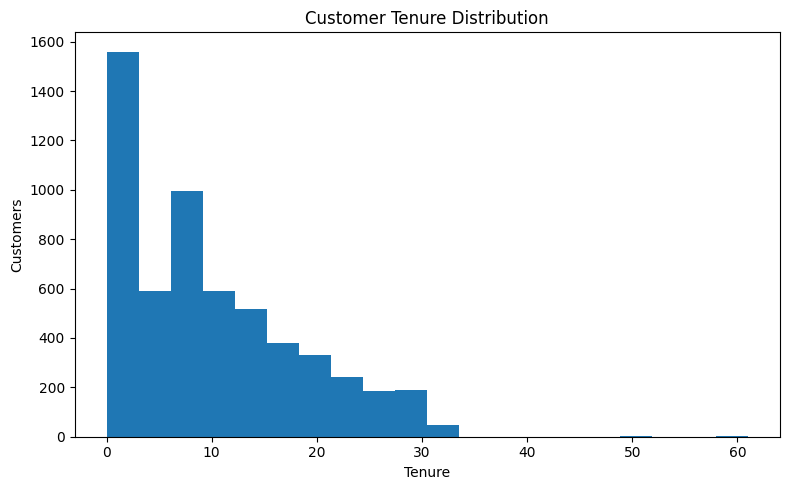

In [34]:
plt.figure(figsize=(8,5))

plt.hist(df["Tenure"],bins=20)

plt.title("Customer Tenure Distribution")

plt.xlabel("Tenure")

plt.ylabel("Customers")

plt.tight_layout()

plt.savefig("visuals/tenure_distribution.png",dpi=300)

plt.show()

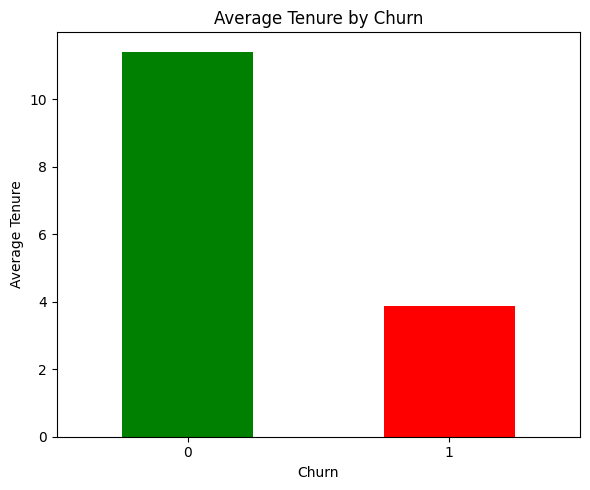

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

tenure_churn = df.groupby("Churn")["Tenure"].mean()

plt.figure(figsize=(6,5))

tenure_churn.plot(
    kind="bar",
    color=["green","red"]
)

plt.title("Average Tenure by Churn")

plt.ylabel("Average Tenure")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("visuals/tenure_vs_churn.png",dpi=300)

plt.show()

<Figure size 800x500 with 0 Axes>

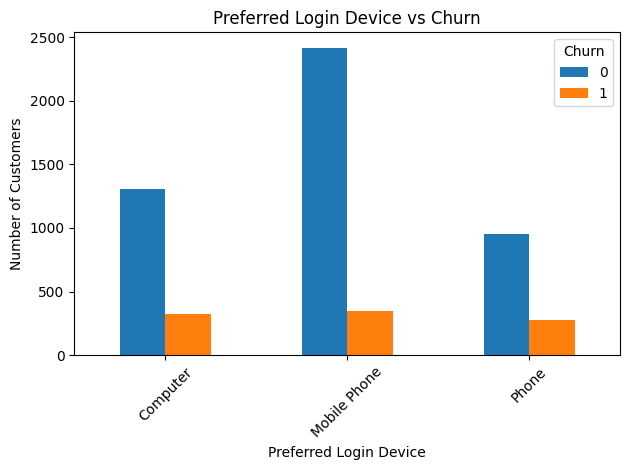

In [36]:
login_churn = pd.crosstab(df["PreferredLoginDevice"], df["Churn"])

plt.figure(figsize=(8,5))

login_churn.plot(kind="bar")

plt.title("Preferred Login Device vs Churn")
plt.xlabel("Preferred Login Device")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("visuals/login_device_vs_churn.png", dpi=300)

plt.show()

<Figure size 800x500 with 0 Axes>

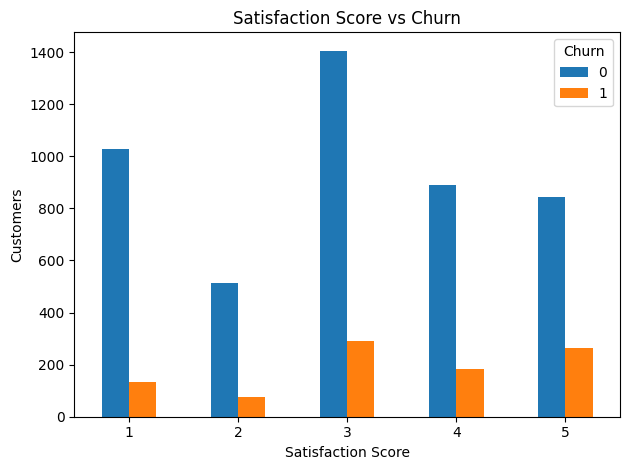

In [37]:
satisfaction = pd.crosstab(df["SatisfactionScore"], df["Churn"])

plt.figure(figsize=(8,5))

satisfaction.plot(kind="bar")

plt.title("Satisfaction Score vs Churn")
plt.xlabel("Satisfaction Score")
plt.ylabel("Customers")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("visuals/satisfaction_vs_churn.png", dpi=300)

plt.show()

<Figure size 600x500 with 0 Axes>

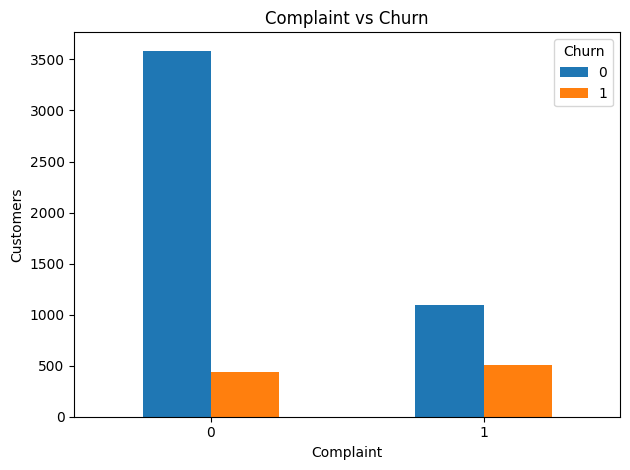

In [38]:
complain = pd.crosstab(df["Complain"], df["Churn"])

plt.figure(figsize=(6,5))

complain.plot(kind="bar")

plt.title("Complaint vs Churn")
plt.xlabel("Complaint")
plt.ylabel("Customers")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("visuals/complaint_vs_churn.png", dpi=300)

plt.show()

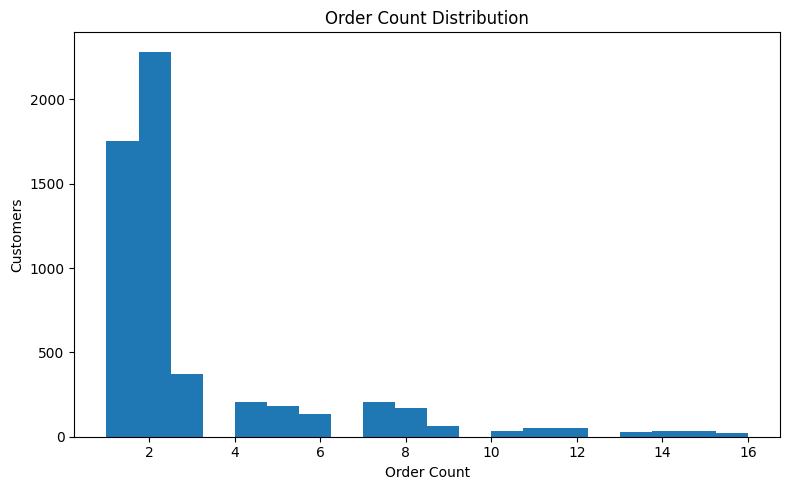

In [39]:
plt.figure(figsize=(8,5))

plt.hist(df["OrderCount"], bins=20)

plt.title("Order Count Distribution")
plt.xlabel("Order Count")
plt.ylabel("Customers")

plt.tight_layout()

plt.savefig("visuals/order_count_distribution.png", dpi=300)

plt.show()

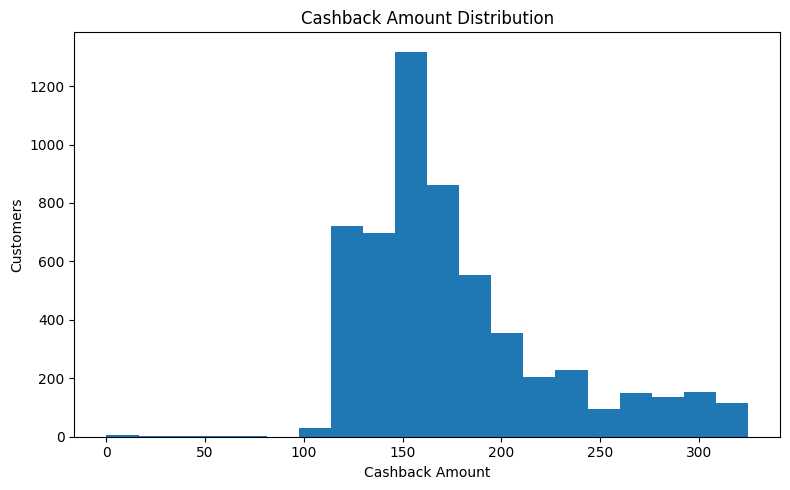

In [40]:
plt.figure(figsize=(8,5))

plt.hist(df["CashbackAmount"], bins=20)

plt.title("Cashback Amount Distribution")
plt.xlabel("Cashback Amount")
plt.ylabel("Customers")

plt.tight_layout()

plt.savefig("visuals/cashback_distribution.png", dpi=300)

plt.show()

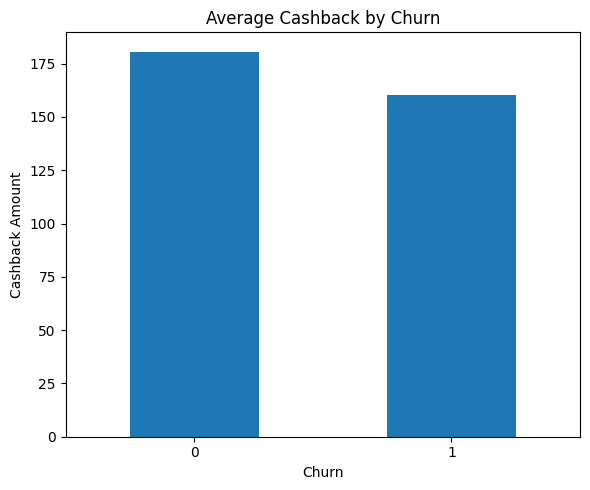

In [41]:
cashback = df.groupby("Churn")["CashbackAmount"].mean()

plt.figure(figsize=(6,5))

cashback.plot(kind="bar")

plt.title("Average Cashback by Churn")
plt.ylabel("Cashback Amount")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("visuals/cashback_vs_churn.png", dpi=300)

plt.show()

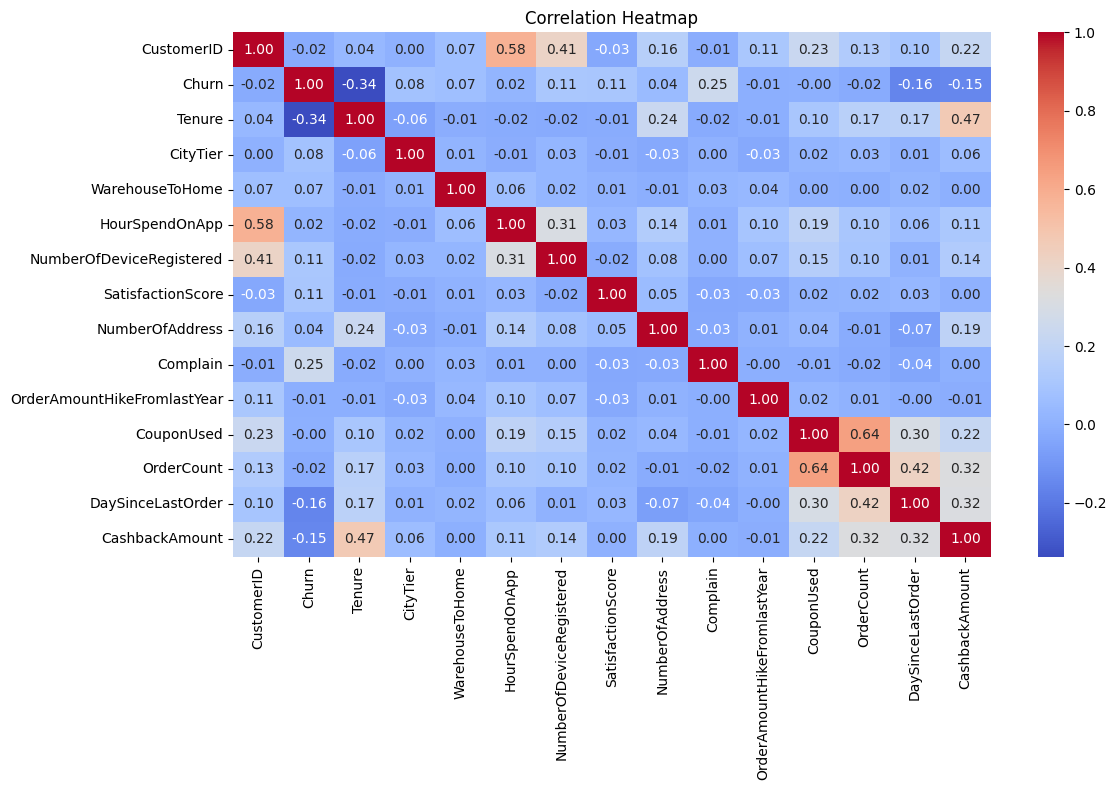

In [42]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("visuals/correlation_heatmap.png", dpi=300)

plt.show()

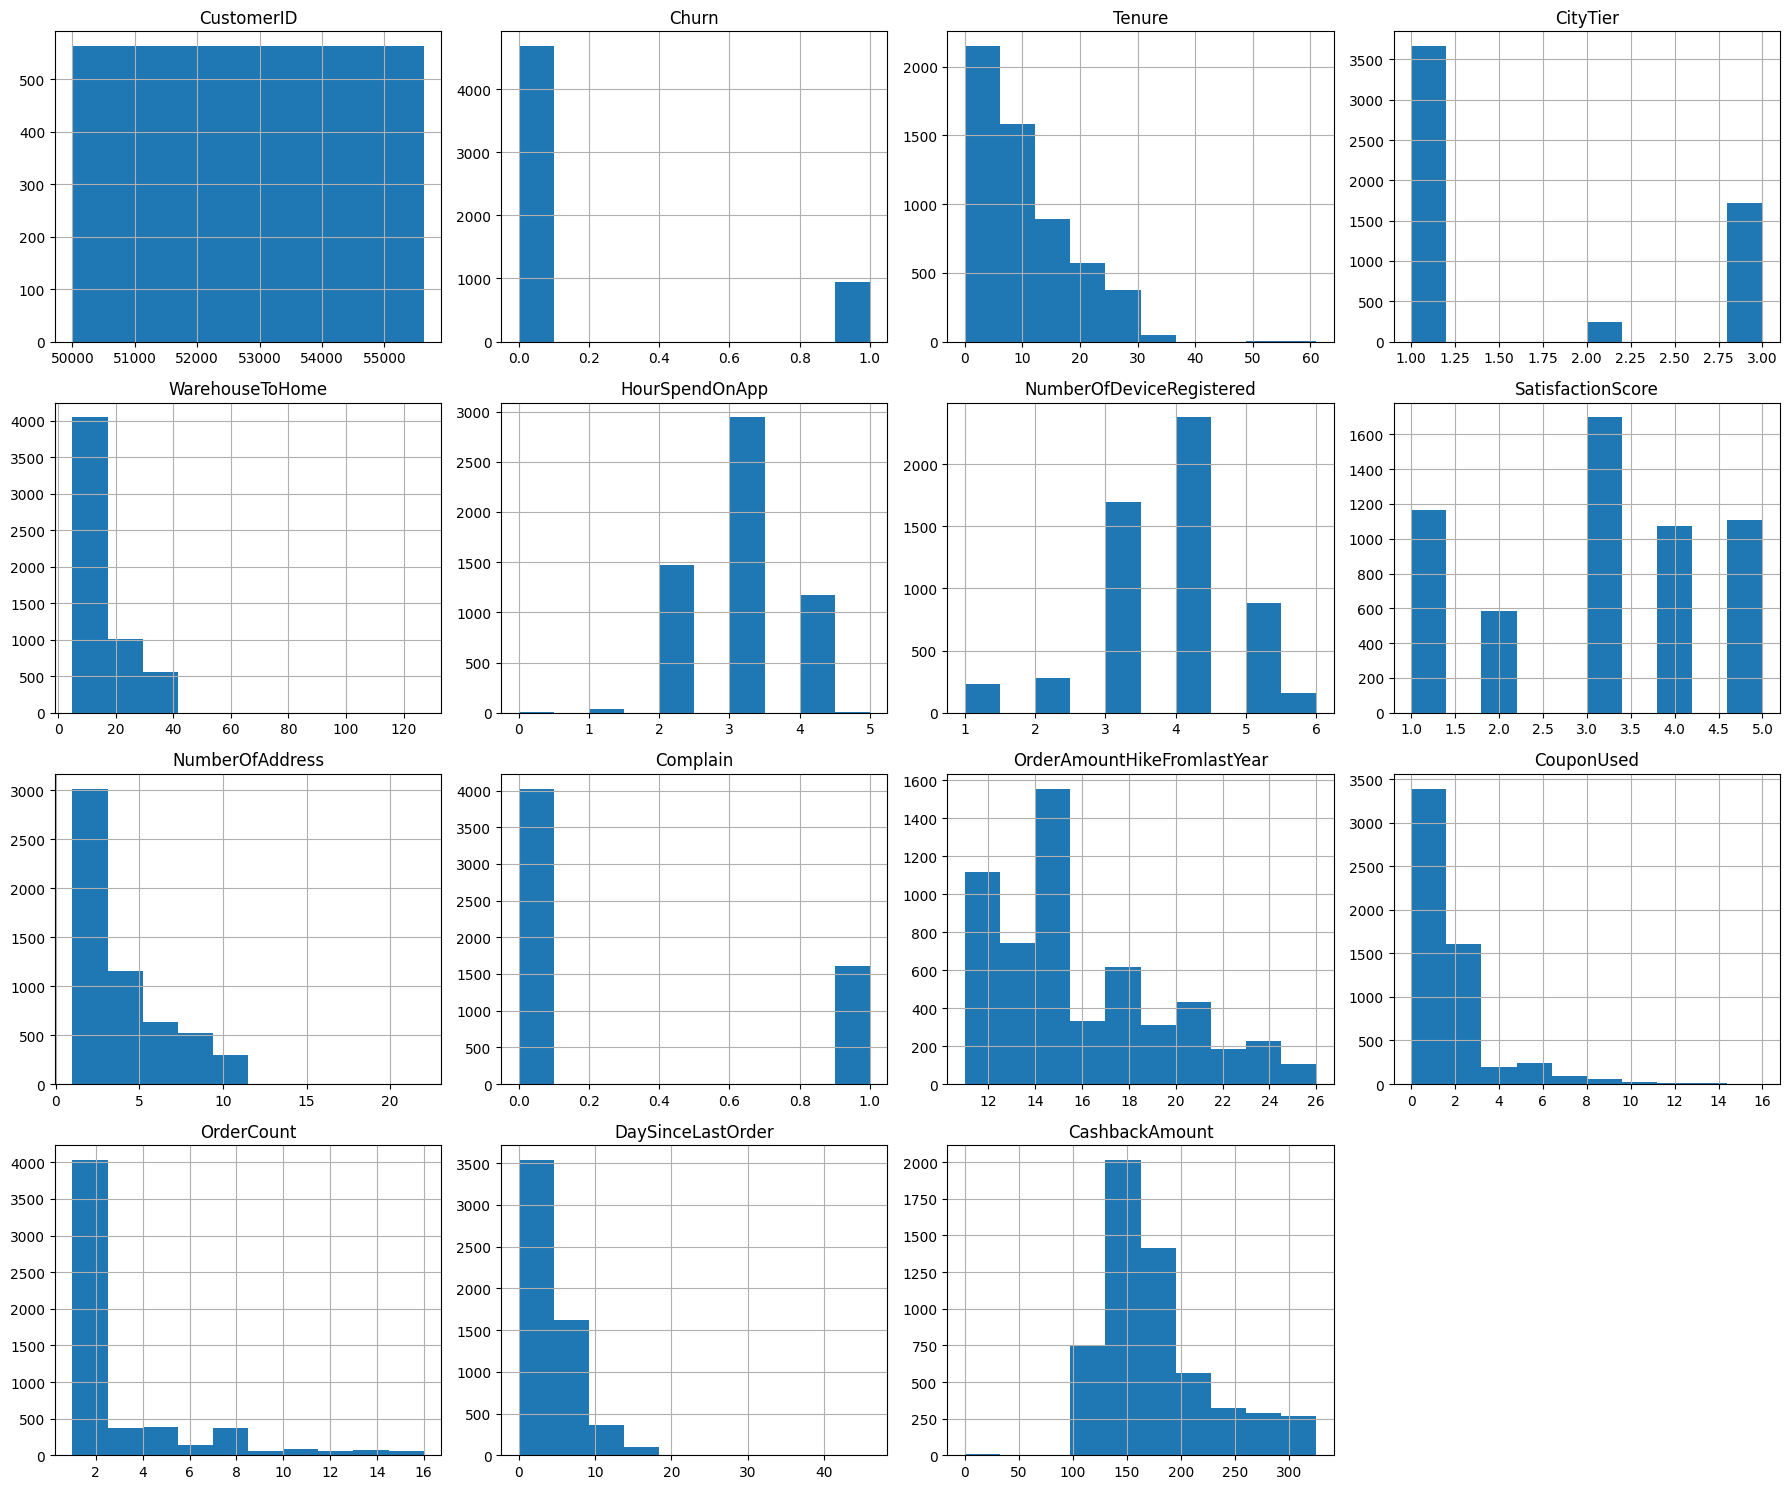

In [43]:
df.hist(figsize=(18,15))

plt.tight_layout()

plt.savefig("visuals/numerical_features_distribution.png", dpi=300)

plt.show()

In [44]:
df.drop("CustomerID", axis=1, inplace=True)

In [45]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [46]:
X.select_dtypes(include="object").columns

Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
      dtype='object')

In [47]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [48]:
y.value_counts()

,count
Churn,
0,4682
1,948


In [49]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [52]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(4504, 29)
(1126, 29)
(4504,)
(1126,)


## Feature Engineering

Before training the machine learning model, several preprocessing steps were performed.

The following operations were applied:

- Removed CustomerID
- Separated Features and Target
- Applied One Hot Encoding to categorical variables
- Encoded the target variable
- Split data into training and testing datasets
- Standardized numerical features using StandardScaler

The dataset is now ready for model training.

In [53]:
from sklearn.linear_model import LogisticRegression

In [54]:
log_model = LogisticRegression(max_iter=1000)

In [55]:
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [56]:
log_pred = log_model.predict(X_test)

In [57]:
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy :", log_accuracy)

Logistic Regression Accuracy : 0.88898756660746


In [58]:
from sklearn.metrics import classification_report

print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.91      0.96      0.94       936
           1       0.74      0.52      0.61       190

    accuracy                           0.89      1126
   macro avg       0.83      0.74      0.77      1126
weighted avg       0.88      0.89      0.88      1126



In [59]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, log_pred)

print(cm)

[[902  34]
 [ 91  99]]


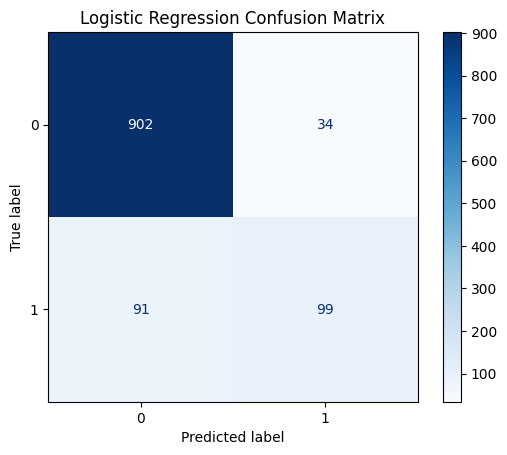

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.savefig("visuals/logistic_confusion_matrix.png",dpi=300)

plt.show()

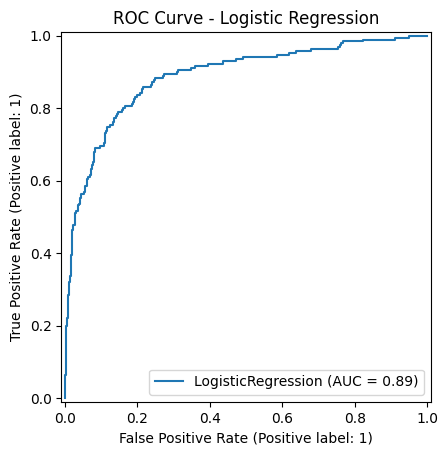

In [61]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    log_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Logistic Regression")

plt.savefig("visuals/logistic_roc_curve.png",dpi=300)

plt.show()

## Logistic Regression

Logistic Regression was selected as the baseline classification algorithm.

The model was trained using the training dataset and evaluated using unseen test data.

Performance was evaluated using:

- Accuracy
- Classification Report
- Confusion Matrix
- ROC Curve

This provides a baseline for comparison with more advanced machine learning models.

In [62]:
from sklearn.tree import DecisionTreeClassifier

In [63]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [64]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [65]:
dt_pred = dt_model.predict(X_test)

In [66]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9662522202486679


In [67]:
from sklearn.metrics import classification_report

print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       936
           1       0.90      0.90      0.90       190

    accuracy                           0.97      1126
   macro avg       0.94      0.94      0.94      1126
weighted avg       0.97      0.97      0.97      1126



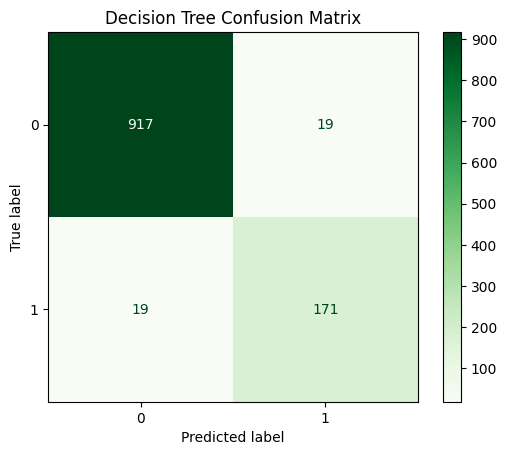

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    dt_model,
    X_test,
    y_test,
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")

plt.savefig(
    "visuals/decision_tree_confusion_matrix.png",
    dpi=300
)

plt.show()

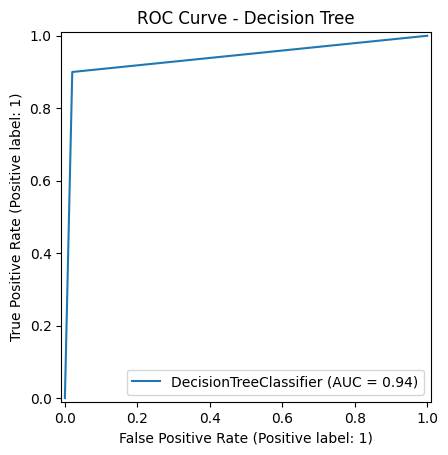

In [69]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    dt_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Decision Tree")

plt.savefig(
    "visuals/decision_tree_roc_curve.png",
    dpi=300
)

plt.show()

In [70]:
from sklearn.ensemble import RandomForestClassifier

In [71]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [72]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [73]:
rf_pred = rf_model.predict(X_test)

In [74]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9822380106571936


In [75]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       936
           1       0.99      0.90      0.94       190

    accuracy                           0.98      1126
   macro avg       0.99      0.95      0.97      1126
weighted avg       0.98      0.98      0.98      1126



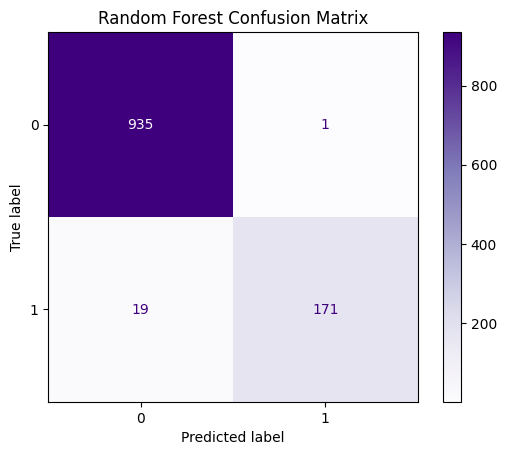

In [76]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Purples"
)

plt.title("Random Forest Confusion Matrix")

plt.savefig(
    "visuals/random_forest_confusion_matrix.png",
    dpi=300
)

plt.show()

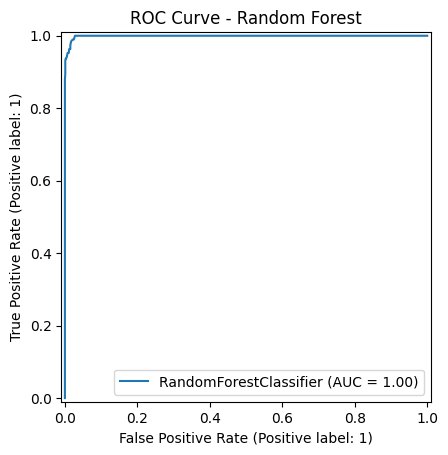

In [77]:
RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")

plt.savefig(
    "visuals/random_forest_roc_curve.png",
    dpi=300
)

plt.show()

In [78]:
model_results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        log_accuracy,
        dt_accuracy,
        rf_accuracy
    ]

})

model_results = model_results.sort_values(
    by="Accuracy",
    ascending=False
)

model_results

,Model,Accuracy
2,Random Forest,0.982238
1,Decision Tree,0.966252
0,Logistic Regression,0.888988


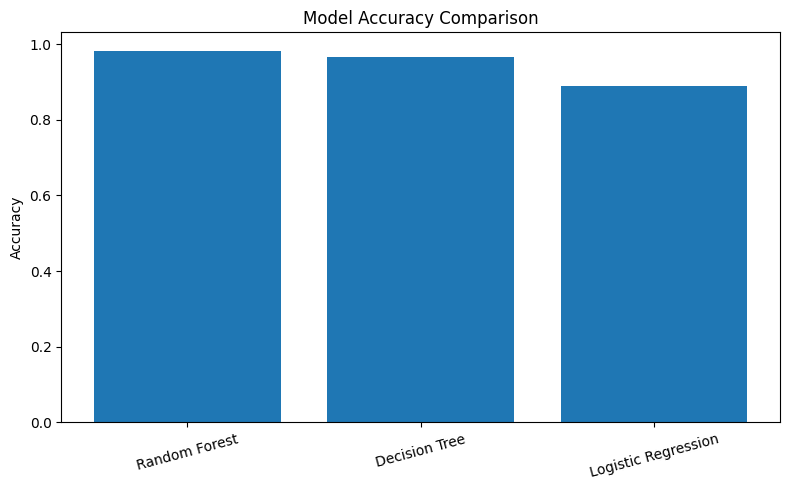

In [79]:
plt.figure(figsize=(8,5))

plt.bar(
    model_results["Model"],
    model_results["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "visuals/model_accuracy_comparison.png",
    dpi=300
)

plt.show()

In [80]:
best_model = model_results.iloc[0]

print("Best Model :", best_model["Model"])

print("Accuracy :", round(best_model["Accuracy"]*100,2),"%")

Best Model : Random Forest
Accuracy : 98.22 %


In [81]:
feature_importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

feature_importance.head(10)

,Feature,Importance
0,Tenure,0.199318
12,CashbackAmount,0.102051
2,WarehouseToHome,0.072079
7,Complain,0.063580
11,DaySinceLastOrder,0.061417
6,NumberOfAddress,0.060158
8,OrderAmountHikeFromlastYear,0.057540
5,SatisfactionScore,0.050887
4,NumberOfDeviceRegistered,0.038710
10,OrderCount,0.032687


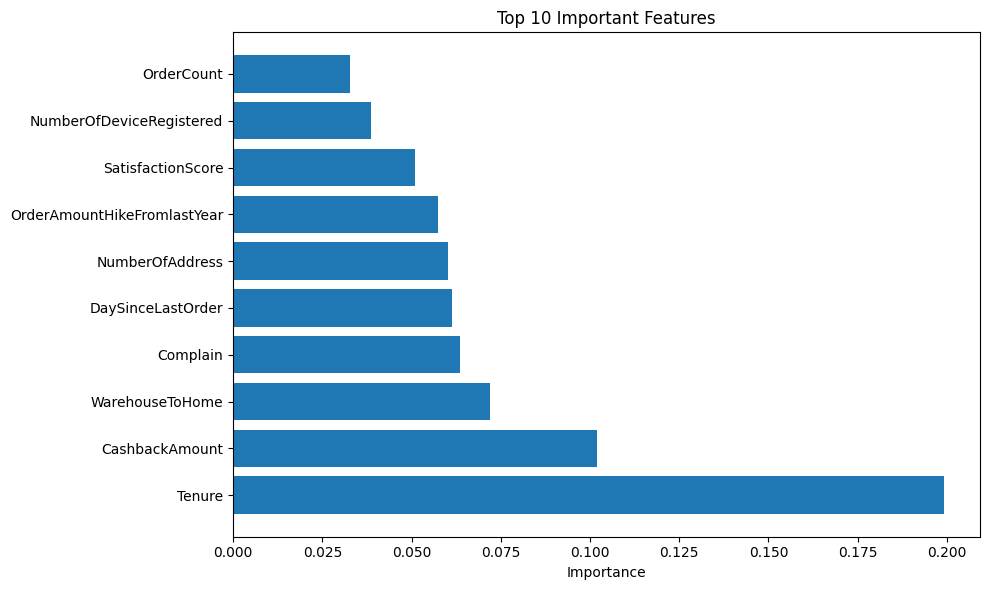

In [82]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(

    top10["Feature"],

    top10["Importance"]

)

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.tight_layout()

plt.savefig(

    "visuals/feature_importance.png",

    dpi=300

)

plt.show()

## Model Comparison

Three machine learning models were trained and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

Among all models, **Random Forest achieved the highest accuracy**, making it the most effective model for customer churn prediction on this dataset.

Random Forest also provided feature importance scores, allowing us to identify the business factors that contribute most to customer churn.

In [83]:
from sklearn.metrics import roc_auc_score

log_auc = roc_auc_score(
    y_test,
    log_model.predict_proba(X_test)[:,1]
)

print("Logistic Regression AUC :",round(log_auc,4))

Logistic Regression AUC : 0.8873


In [84]:
dt_auc = roc_auc_score(
    y_test,
    dt_model.predict_proba(X_test)[:,1]
)

print("Decision Tree AUC :",round(dt_auc,4))

Decision Tree AUC : 0.9399


In [85]:
rf_auc = roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test)[:,1]
)

print("Random Forest AUC :",round(rf_auc,4))


Random Forest AUC : 0.999


In [86]:
comparison = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest"

    ],

    "Accuracy":[

        log_accuracy,

        dt_accuracy,

        rf_accuracy

    ],

    "ROC_AUC":[

        log_auc,

        dt_auc,

        rf_auc

    ]

})

comparison.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

comparison

,Model,Accuracy,ROC_AUC
2,Random Forest,0.982238,0.999033
1,Decision Tree,0.966252,0.939850
0,Logistic Regression,0.888988,0.887286


In [87]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

In [88]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [89]:
print("="*60)

print("FINAL MODEL SELECTION")

print("="*60)

print(f"Best Model : {comparison.iloc[0]['Model']}")

print(f"Accuracy : {comparison.iloc[0]['Accuracy']:.4f}")

print(f"ROC AUC : {comparison.iloc[0]['ROC_AUC']:.4f}")

FINAL MODEL SELECTION
Best Model : Random Forest
Accuracy : 0.9822
ROC AUC : 0.9990


## Final Model Selection

Three classification algorithms were trained and evaluated.

The models were compared using:

- Accuracy
- ROC-AUC Score

Random Forest achieved the highest predictive performance and was selected as the final model.

The model also provides feature importance, making it easier to explain business decisions.

# Key Business Insights

- The dataset contained **5,630 customer records** with demographic, behavioral, and transactional information.

- Missing values and duplicate records were handled to improve data quality before model training.

- Exploratory Data Analysis showed that **customer tenure, complaints, satisfaction score, cashback, and order behavior** have a strong impact on customer churn.

- Customers with **lower tenure** were more likely to churn, highlighting the importance of early customer engagement.

- Customers who raised **complaints** showed a higher probability of leaving the company.

- Higher **customer satisfaction** was associated with better customer retention.

- Feature Importance analysis identified the most influential variables affecting churn prediction.

- Three machine learning models were evaluated: **Logistic Regression, Decision Tree, and Random Forest**.

- **Random Forest achieved the highest accuracy** among all models and delivered the best overall predictive performance.

- The trained model can help the business identify high-risk customers early and support data-driven retention strategies.

# Business Recommendation

- Improve customer onboarding for new customers.
- Resolve customer complaints more quickly.
- Increase customer satisfaction through better service.
- Provide personalized cashback and loyalty offers to high-risk customers.
- Deploy the Random Forest model for churn prediction due to its superior performance.

# Conclusion

This project successfully developed an end-to-end Customer Churn Prediction pipeline, including data cleaning, exploratory data analysis, feature engineering, machine learning, and model evaluation.

Among all evaluated models, **Random Forest achieved the highest predictive performance** and was selected as the final model for customer churn prediction. The analysis demonstrates how machine learning can help businesses identify at-risk customers and improve retention through data-driven decision-making.

In [90]:
report = f"""
=========================================================
        CUSTOMER CHURN PREDICTION REPORT
=========================================================

PROJECT
---------------------------------------------------------
Customer Churn Prediction using Machine Learning

=========================================================
OBJECTIVE
=========================================================

Predict customers who are likely to leave the company
using historical customer behavior and demographic data.

=========================================================
DATASET SUMMARY
=========================================================

Total Records : {len(df)}
Total Features: {df.shape[1]}

=========================================================
MODELS TRAINED
=========================================================

1. Logistic Regression
2. Decision Tree
3. Random Forest

=========================================================
MODEL PERFORMANCE
=========================================================

Logistic Regression Accuracy : {log_accuracy:.4f}

Decision Tree Accuracy       : {dt_accuracy:.4f}

Random Forest Accuracy       : {rf_accuracy:.4f}

=========================================================
BEST MODEL
=========================================================

Random Forest

=========================================================
KEY FINDINGS
=========================================================

• Missing values successfully handled.

• Data cleaned and prepared for ML.

• Customer behavior strongly influences churn.

• Complaint, Tenure and Satisfaction were among the
  important factors affecting churn.

• Random Forest achieved the highest predictive performance.

=========================================================
BUSINESS RECOMMENDATION
=========================================================

• Improve onboarding.

• Resolve complaints faster.

• Increase customer satisfaction.

• Launch personalized retention campaigns.

• Deploy the Random Forest model.

=========================================================
END OF REPORT
=========================================================
"""

print(report)

with open("customer_churn_report.txt","w") as file:
    file.write(report)

print("customer_churn_report.txt created successfully.")


        CUSTOMER CHURN PREDICTION REPORT

PROJECT
---------------------------------------------------------
Customer Churn Prediction using Machine Learning

OBJECTIVE

Predict customers who are likely to leave the company
using historical customer behavior and demographic data.

DATASET SUMMARY

Total Records : 5630
Total Features: 19

MODELS TRAINED

1. Logistic Regression
2. Decision Tree
3. Random Forest

MODEL PERFORMANCE

Logistic Regression Accuracy : 0.8890

Decision Tree Accuracy       : 0.9663

Random Forest Accuracy       : 0.9822

BEST MODEL

Random Forest

KEY FINDINGS

• Missing values successfully handled.

• Data cleaned and prepared for ML.

• Customer behavior strongly influences churn.

• Complaint, Tenure and Satisfaction were among the
  important factors affecting churn.

• Random Forest achieved the highest predictive performance.

BUSINESS RECOMMENDATION

• Improve onboarding.

• Resolve complaints faster.

• Increase customer satisfaction.

• Launch personaliz

In [91]:
from google.colab import files

files.download("customer_churn_report.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [92]:
files.download("model_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [93]:
files.download("feature_importance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [94]:
import shutil

# Create a zip file of all graphs
shutil.make_archive("visuals", "zip", "visuals")

print("visuals.zip created successfully!")

visuals.zip created successfully!


In [95]:
from google.colab import files

files.download("visuals.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>